**Paso 1: Instalar e importar las librerías necesarias**

In [2]:
!pip install nltk

Defaulting to user installation because normal site-packages is not writeable


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

# NLP
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import RegexpTokenizer

# ML
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, roc_auc_score, roc_curve, ConfusionMatrixDisplay
)
from sklearn.pipeline import Pipeline

# Descarga de recursos NLTK
for resource in ['stopwords', 'wordnet', 'omw-1.4']:
    nltk.download(resource, quiet=True)

print("Todas las librerías importadas correctamente.")

Todas las librerías importadas correctamente.


**Paso 2: Carga y exploración del dataset**

In [4]:
url = "https://breathecode.herokuapp.com/asset/internal-link?id=932&path=url_spam.csv"
df = pd.read_csv(url)
print(f"Dataset: {df.shape[0]} filas × {df.shape[1]} columnas")

Dataset: 2999 filas × 2 columnas


In [5]:
df.head(10)

,url,is_spam
0,https://briefingday.us8.list-manage.com/unsubs...,True
1,https://www.hvper.com/,True
2,https://briefingday.com/m/v4n3i4f3,True
3,https://briefingday.com/n/20200618/m#commentform,False
4,https://briefingday.com/fan,True
5,https://www.brookings.edu/interactives/reopeni...,False
6,https://www.reuters.com/investigates/special-r...,False
7,https://www.theatlantic.com/magazine/archive/2...,False
8,https://www.vox.com/2020/6/17/21294680/john-bo...,False
9,https://www.theguardian.com/travel/2020/jun/18...,False


In [6]:
df.tail(10)

,url,is_spam
2989,https://thehustle.co/07012020-National-Researc...,False
2990,https://www.nytimes.com/2020/06/30/technology/...,False
2991,https://thehustle.co/07012020-deepfakes-AI/,False
2992,https://www.technologyreview.com/2019/12/12/13...,False
2993,https://www.theverge.com/2020/6/29/21306889/di...,False
2994,https://www.smartcitiesworld.net/news/news/dee...,False
2995,https://www.youtube.com/watch,True
2996,https://techcrunch.com/2019/07/04/an-optimisti...,False
2997,https://www.technologyreview.com/2019/12/20/13...,False
2998,https://www.bbc.com/news/technology-51018758,False


In [7]:
print("Columnas:", df.columns.tolist())

Columnas: ['url', 'is_spam']


In [8]:
print("\nTipos de datos:")
print(df.dtypes)


Tipos de datos:
url         str
is_spam    bool
dtype: object


In [9]:
print("\nValores nulos:")
print(df.isnull().sum())


Valores nulos:
url        0
is_spam    0
dtype: int64


In [10]:
# Asumo que la primera columna es la URL y la segunda es la etiqueta
df.columns = ['url', 'label']

# Elimino duplicados y nulos
df.drop_duplicates(inplace=True)
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)

print(f"Dataset limpio: {df.shape[0]} registros")

Dataset limpio: 2369 registros


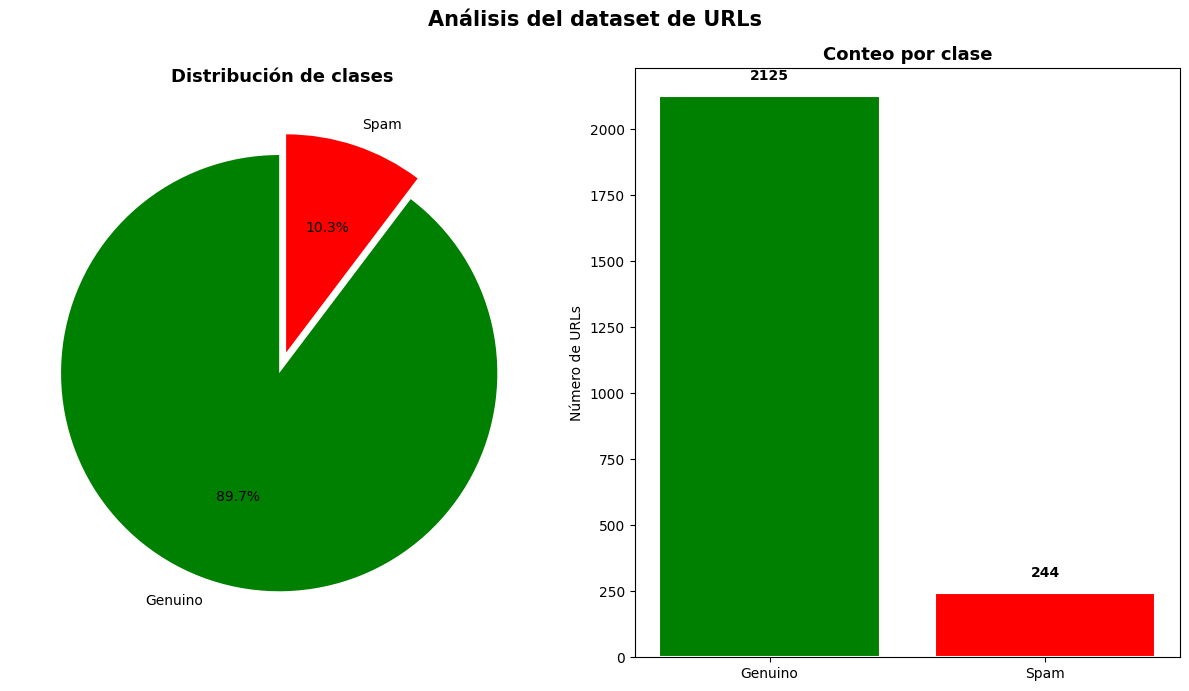

In [11]:
# Distribución de clases
fig, axes = plt.subplots(1, 2, figsize=(12, 7))

class_counts = df['label'].value_counts()
labels_map = {0: 'Genuino', 1: 'Spam'}

# Gráfico circular
axes[0].pie(
    class_counts, 
    labels=[labels_map.get(i, str(i)) for i in class_counts.index],
    autopct='%1.1f%%',
    colors=['green', 'red'],
    startangle=90,
    explode=(0.05, 0.05)
)
axes[0].set_title('Distribución de clases', fontsize=13, fontweight='bold')

# Gráfico de barras
bars = axes[1].bar(
    [labels_map.get(i, str(i)) for i in class_counts.index],
    class_counts.values,
    color=['green', 'red'],
    edgecolor='white',
    linewidth=1.5
)
for bar, count in zip(bars, class_counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 str(count), ha='center', va='bottom', fontweight='bold')
axes[1].set_title('Conteo por clase', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Número de URLs')
axes[1].set_facecolor('white')

plt.suptitle('Análisis del dataset de URLs', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

In [12]:
print("\nDistribución de clases:")
for k, v in class_counts.items():
    print(f"- {labels_map.get(k, k)}: {v} ({v/len(df)*100:.2f} %)")


Distribución de clases:
- Genuino: 2125 (89.70 %)
- Spam: 244 (10.30 %)


In [13]:
# Análisis exploratorio de las URLs
df['url_length'] = df['url'].apply(len)
df['num_dots'] = df['url'].apply(lambda x: x.count('.'))
df['num_hyphens'] = df['url'].apply(lambda x: x.count('-'))
df['num_digits'] = df['url'].apply(lambda x: sum(c.isdigit() for c in x))
df['has_https'] = df['url'].apply(lambda x: int(x.startswith('https')))
df['num_special'] = df['url'].apply(lambda x: len(re.findall(r'[^a-zA-Z0-9./:_-]', x)))

print("Estadísticas descriptivas de las URLs:")
df[['url_length', 'num_dots', 'num_hyphens', 'num_digits', 'num_special']].groupby(
    df['label']).agg(['mean', 'median', 'std']).round(2)

Estadísticas descriptivas de las URLs:


url_length               num_dots              num_hyphens               \
            mean median    std     mean median   std        mean median   std   
label                                                                           
False      82.05   81.0  34.57     1.97    2.0  0.70        5.43    5.0  4.55   
True       49.65   46.0  20.68     1.91    2.0  0.55        1.66    1.0  2.17   

      num_digits              num_special               
            mean median   std        mean median   std  
label                                                   
False       7.16    7.0  7.03        0.30    0.0  1.79  
True        1.59    0.0  3.85        0.02    0.0  0.18

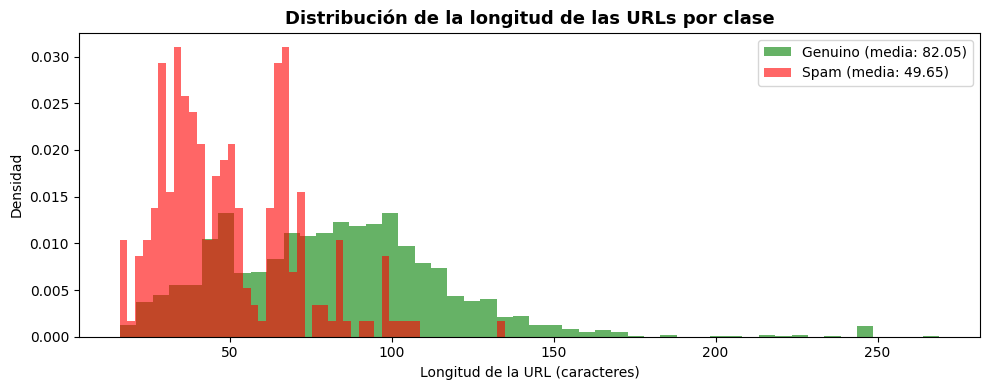

In [14]:
# Distribución de la longitud de las URLs por clase
fig, ax = plt.subplots(figsize=(10, 4))

for label, color, name in [(0, 'green', 'Genuino'), (1, 'red', 'Spam')]:
    subset = df[df['label'] == label]['url_length']
    ax.hist(subset, bins=50, alpha=0.6, color=color, label=f'{name} (media: {subset.mean():.2f})', density=True)

ax.set_xlabel('Longitud de la URL (caracteres)')
ax.set_ylabel('Densidad')
ax.set_title('Distribución de la longitud de las URLs por clase', fontsize=13, fontweight='bold')
ax.legend()
ax.set_facecolor('white')
plt.tight_layout()
plt.show()

**Paso 3: Preprocesado NLP de las URLs**

In [15]:
# Configuración del preprocesador
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

# También ignoro las palabras muy comunes o que no aportan información en las URLs
url_noise = {'www', 'com', 'http', 'https', 'html', 'php', 'org',
             'net', 'co', 'uk', 'io', 'asp', 'htm', 'jsp', 'cgi'}
stop_words = stop_words.union(url_noise)

def preprocess_url(url: str) -> str:
    """
    Preprocesa una URL aplicando:
    - Conversión a minúsculas
    - Tokenización por signos de puntuación y separadores URL
    - Eliminación de tokens numéricos puros
    - Eliminación de stopwords
    - Lematización
    
    Devuelve un string con tokens procesados y separados por espacios.
    """
    # 1. Minúsculas
    url = url.lower()
    
    # 2. Elimino el protocolo
    url = re.sub(r'https?://', '', url)
    
    # 3. Tokenizar: dividir por puntuación, guiones, números y separadores URL
    tokens = re.split(r'[./:?=&\-_+%@#~,;!]', url)
    
    # 4. Separar tokens que mezclan letras y números
    expanded = []
    for token in tokens:
        parts = re.findall(r'[a-z]+|[0-9]+', token)
        expanded.extend(parts)
    
    # 5. Filtro solo tokens alfabéticos que tengan una longitud >= 3
    tokens = [t for t in expanded if t.isalpha() and len(t) >= 3]
    
    # 6. Elimino stopwords
    tokens = [t for t in tokens if t not in stop_words]
    
    # 7. Lematizar
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    
    return ' '.join(tokens)

# Ejemplos del dataset
df['url'].head(20).tolist()
spam_examples = df[df['label'] == 1]['url'].head(2).tolist()
legit_examples = df[df['label'] == 0]['url'].head(2).tolist()
examples = legit_examples + spam_examples

print("Ejemplos de preprocesado:\n")
for url in examples:
    print(f"- Original: {url}")
    print(f"- Procesado: {preprocess_url(url)}")

Ejemplos de preprocesado:

- Original: https://briefingday.com/n/20200618/m#commentform
- Procesado: briefingday commentform
- Original: https://www.brookings.edu/interactives/reopening-america-and-the-world/
- Procesado: brookings edu interactives reopening america world
- Original: https://briefingday.us8.list-manage.com/unsubscribe
- Procesado: briefingday list manage unsubscribe
- Original: https://www.hvper.com/
- Procesado: hvper


In [16]:
# Aplico el preprocesado al dataset completo
print("Preprocesando URLs...")
df['url_processed'] = df['url'].apply(preprocess_url)

# Elimino aquellas filas cuyo procesado quede vacío
df = df[df['url_processed'].str.strip() != '']
df.reset_index(drop=True, inplace=True)

print(f"Preprocesado completo. {len(df)} URLs válidas.")
print("\nResultado:")
df[['url', 'url_processed', 'label']].head(10)

Preprocesando URLs...
Preprocesado completo. 2369 URLs válidas.

Resultado:


,url,url_processed,label
0,https://briefingday.us8.list-manage.com/unsubs...,briefingday list manage unsubscribe,True
1,https://www.hvper.com/,hvper,True
2,https://briefingday.com/m/v4n3i4f3,briefingday,True
3,https://briefingday.com/n/20200618/m#commentform,briefingday commentform,False
4,https://briefingday.com/fan,briefingday fan,True
5,https://www.brookings.edu/interactives/reopeni...,brookings edu interactives reopening america w...,False
6,https://www.reuters.com/investigates/special-r...,reuters investigates special report health cor...,False
7,https://www.theatlantic.com/magazine/archive/2...,theatlantic magazine archive supermarket miracle,False
8,https://www.vox.com/2020/6/17/21294680/john-bo...,vox john bolton book excerpt trump ukraine china,False
9,https://www.theguardian.com/travel/2020/jun/18...,theguardian travel jun end tourism coronavirus...,False


**Paso 4: División en train y test**

In [17]:
# Divido el dataset en **80 % train** y **20 % test** y mantengo la proporción de clases con stratify.
X = df['url_processed']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("División del dataset:")
print(f"- Train: {len(X_train)} muestras ({len(X_train)/len(X)*100:.2f} %)")
print(f"- Test:  {len(X_test)} muestras  ({len(X_test)/len(X)*100:.2f} %)")
print(f"Distribución train \n- Spam: {y_train.mean()*100:.2f} % | Genuino: {(1-y_train.mean())*100:.2f} %")
print(f"Distribución test  \n- Spam: {y_test.mean()*100:.2f} % | Genuino: {(1-y_test.mean())*100:.2f} %")

División del dataset:
- Train: 1895 muestras (79.99 %)
- Test:  474 muestras  (20.01 %)
Distribución train 
- Spam: 10.29 % | Genuino: 89.71 %
Distribución test  
- Spam: 10.34 % | Genuino: 89.66 %


**Paso 5: SVM con parámetros por defecto**

- Quiero crear un pipeline que:
1. Vectorice el texto con **TF-IDF** (convierte tokens a vectores numéricos).
2. Entrene un **SVM** (kernel='rbf').
-  Quiero que el TF-IDF solo aprenda del conjunto de training.

In [18]:
# Pipeline: TF-IDF + SVM
pipeline_baseline = Pipeline([
    ('tfidf', TfidfVectorizer(
        analyzer='word',
        ngram_range=(1, 2),
        max_features=10000,
        sublinear_tf=True
    )),
    ('svm', SVC(
        kernel='rbf',
        probability=True, # Necesario para ROC-AUC
        random_state=42
    ))
])

# Entrenamiento
print("Entrenando SVM...")
pipeline_baseline.fit(X_train, y_train)
print("Entrenamiento completado.")

Entrenando SVM...
Entrenamiento completado.


**Paso 6: Optimización de hiperparámetros**

**Paso 7: Guardar el modelo**

**Paso 8: Predicción sobre nuevas URLs**

**Paso 9: Conclusiones**

- **Dataset original:** 2999 filas × 2 columnas
- **Dataset limpio:** 2369 registros
- **Distribución de clases:** URLs genuinas: 2125 (89.70 %) vs. spam: 244 (10.30 %)
- **Pipeline:** URL original -> Preprocesado NLP -> TF-IDF -> SVM -> Predicción

**Técnicas NLP aplicadas**
- **Tokenización:** Segmentación por signos de puntuación
- **Normalización:** Conversión a minúsculas y filtrado de tokens cortos
- **Eliminación de stopwords:** Eliminación de palabras comunes (NLTK + palabras de las URLs)
- **Lematización:** Reducción de palabras a su forma base (WordNetLemmatizer)
- **TF-IDF:** Vectorización + ngram_range

**Resultados**
| Modelo | Accuracy | ROC-AUC |
|---|---|---|
| SVM base (parámetros por defecto) | — | — |
| SVM optimizado (RandomizedSearchCV) | — | — |